In [1]:
from jormungandr.fafnir import Fafnir
from jormungandr.backbone import Backbone
from jormungandr.dataset import create_dataloaders
from jormungandr.config.configuration import load_config
import torch
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from supervision import Detections
from transformers.image_transforms import center_to_corners_format



from transformers import DetrImageProcessor, DetrForObjectDetection
from transformers.loss.loss_for_object_detection import HungarianMatcher
from jormungandr.training.criterion import HungarianMatcherWithCIoU


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
config = load_config("detr.yaml")
fafnir = Fafnir(config=config.fafnir)

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
train_loader, val_loader = create_dataloaders()

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

In [4]:
image_processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
matcher = HungarianMatcher().to(fafnir.device)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


with torch.no_grad():
    for batch in val_loader:
        pixel_values, pixel_mask, labels = (
                batch["pixel_values"],
                batch["pixel_mask"],
                batch["labels"],
            )
        pixel_values = pixel_values.to(device)
        pixel_mask = pixel_mask.to(device)
        labels = [{k: v.to(device) for k, v in label.items()} for label in labels]

        class_logits, bbox_coordinates = fafnir.forward(pixel_values)

        print(f"Class logits shape: {class_logits.shape}")
        print(f"bbox_coordinates.shape: {bbox_coordinates.shape}")
        
        outputs = {
            "logits": class_logits,
            "pred_boxes": bbox_coordinates,
        }
        matched_indices = matcher.forward(outputs, labels)
        print(f"matched_indices: {matched_indices[0]}")
        print(f"Example labels: {labels[0]}")
        print(f"Example outputs: {torch.argmax(outputs['logits'][0], dim=-1)}")

        break
                

Class logits shape: torch.Size([32, 100, 92])
bbox_coordinates.shape: torch.Size([32, 100, 4])
matched_indices: (tensor([ 1,  3,  4, 15, 21, 24, 25, 26, 27, 36, 40, 59, 71, 78, 80, 87, 89, 91,
        92, 97]), tensor([15,  8,  0,  1, 11, 16,  5,  2,  4, 12,  9, 18, 19, 17, 14,  7,  3, 10,
         6, 13]))
Example labels: {'size': tensor([1207, 1333], device='cuda:0'), 'image_id': tensor([139], device='cuda:0'), 'class_labels': tensor([64, 72, 72, 62, 62, 62, 62,  1,  1, 78, 82, 84, 84, 85, 86, 86, 62, 86,
        86, 67], device='cuda:0'), 'boxes': tensor([[0.5178, 0.3867, 0.3684, 0.3299],
        [0.1199, 0.4619, 0.2201, 0.4018],
        [0.8427, 0.4941, 0.1165, 0.3373],
        [0.7032, 0.5010, 0.3956, 0.3235],
        [0.6551, 0.5010, 0.4917, 0.3236],
        [0.7413, 0.5049, 0.3193, 0.3158],
        [0.6739, 0.5020, 0.4541, 0.3217],
        [0.7411, 0.4540, 0.3198, 0.4176],
        [0.7211, 0.4297, 0.3598, 0.3235],
        [0.8110, 0.4915, 0.1799, 0.3427],
        [0.7976, 0.4670

In [6]:
print(f"Type of matched_indices: {type(matched_indices)}")
print(f"Type of class_logits: {type(class_logits)}")
print(f"Type of bbox_coordinates: {type(bbox_coordinates)}")
print(f"Type of labels: {type(labels)}")

Type of matched_indices: <class 'list'>
Type of class_logits: <class 'torch.Tensor'>
Type of bbox_coordinates: <class 'torch.Tensor'>
Type of labels: <class 'list'>


In [7]:
print(matched_indices[0][0].shape) # (20, 1)
print(class_logits[0].shape) # (100, 92)

for batch_matched_indices, batch_labels, batch_class_logits, batch_bbox_coordinates in zip(matched_indices, labels, class_logits, bbox_coordinates):
    # Convert matched indices to the format expected by the metric
    predictions = {
            "logits": batch_class_logits[batch_matched_indices[0].to("cuda")],  # (20, 92)
            "pred_boxes": batch_bbox_coordinates[batch_matched_indices[0].to("cuda")],  # (20, 4)
        }
    
    matched_labels = {
        "labels": batch_labels["class_labels"][batch_matched_indices[1].to("cuda")],  # (20,)
        "boxes": batch_labels["boxes"][batch_matched_indices[1].to("cuda")],  # (20, 4)
    }
    break

torch.Size([20])
torch.Size([100, 92])


In [8]:
predictions["logits"].shape, predictions["pred_boxes"].shape

(torch.Size([20, 92]), torch.Size([20, 4]))

In [9]:
argmax_predictions = torch.argmax(predictions["logits"], dim=-1)
confidences = torch.max(predictions["logits"].softmax(dim=-1), dim=-1).values
print(f"Argmax predictions shape: {argmax_predictions.shape}")

Argmax predictions shape: torch.Size([20])


In [10]:
predictions["pred_boxes"].cpu()

tensor([[0.5339, 0.3588, 0.0203, 0.0368],
        [0.5821, 0.3176, 0.0358, 0.0747],
        [0.5191, 0.3308, 0.0494, 0.0832],
        [0.1154, 0.3526, 0.2299, 0.1691],
        [0.8502, 0.5675, 0.0671, 0.1828],
        [0.6345, 0.4100, 0.0575, 0.1911],
        [0.6125, 0.4304, 0.0803, 0.1663],
        [0.9071, 0.4106, 0.1494, 0.1319],
        [0.4789, 0.4358, 0.0985, 0.1671],
        [0.8486, 0.5684, 0.0648, 0.1826],
        [0.7760, 0.3473, 0.0302, 0.0422],
        [0.6964, 0.4143, 0.5132, 0.1523],
        [0.5510, 0.4301, 0.1932, 0.1616],
        [0.5025, 0.3440, 0.0154, 0.0323],
        [0.8493, 0.5669, 0.0670, 0.1810],
        [0.6581, 0.3760, 0.0757, 0.2382],
        [0.5733, 0.4375, 0.0905, 0.1667],
        [0.7179, 0.3750, 0.1012, 0.1957],
        [0.7207, 0.4966, 0.5429, 0.2971],
        [0.6730, 0.2153, 0.0247, 0.0399]])

In [11]:
# Convert to corner format
predictions["xyxy"] = center_to_corners_format(predictions["pred_boxes"])
predictions["xyxy"], argmax_predictions.cpu()

(tensor([[5.2374e-01, 3.4038e-01, 5.4399e-01, 3.7716e-01],
         [5.6415e-01, 2.8023e-01, 6.0000e-01, 3.5491e-01],
         [4.9441e-01, 2.8923e-01, 5.4385e-01, 3.7244e-01],
         [4.8877e-04, 2.6809e-01, 2.3036e-01, 4.3714e-01],
         [8.1666e-01, 4.7610e-01, 8.8378e-01, 6.5892e-01],
         [6.0573e-01, 3.1446e-01, 6.6321e-01, 5.0561e-01],
         [5.7238e-01, 3.4725e-01, 6.5265e-01, 5.1351e-01],
         [8.3241e-01, 3.4462e-01, 9.8183e-01, 4.7650e-01],
         [4.2959e-01, 3.5227e-01, 5.2812e-01, 5.1938e-01],
         [8.1623e-01, 4.7712e-01, 8.8101e-01, 6.5970e-01],
         [7.6087e-01, 3.2621e-01, 7.9104e-01, 3.6843e-01],
         [4.3981e-01, 3.3814e-01, 9.5299e-01, 4.9040e-01],
         [4.5443e-01, 3.4932e-01, 6.4763e-01, 5.1096e-01],
         [4.9481e-01, 3.2780e-01, 5.1021e-01, 3.6014e-01],
         [8.1578e-01, 4.7642e-01, 8.8277e-01, 6.5740e-01],
         [6.2022e-01, 2.5686e-01, 6.9595e-01, 4.9510e-01],
         [5.2806e-01, 3.5419e-01, 6.1858e-01, 5.2090e-01

In [12]:
matched_labels["xyxy"] = center_to_corners_format(matched_labels["boxes"])
matched_labels["xyxy"], matched_labels["labels"].cpu()

(tensor([[0.4938, 0.3249, 0.9010, 0.6628],
         [0.5412, 0.2679, 0.9010, 0.5915],
         [0.3336, 0.2217, 0.7020, 0.5516],
         [0.0099, 0.2610, 0.2300, 0.6628],
         [0.8514, 0.4759, 0.9010, 0.6628],
         [0.5804, 0.3408, 0.9010, 0.6628],
         [0.5817, 0.3470, 0.9010, 0.6628],
         [0.7844, 0.3255, 0.9010, 0.6628],
         [0.4092, 0.3392, 0.9010, 0.6628],
         [0.8633, 0.4796, 0.9010, 0.6628],
         [0.7211, 0.3201, 0.9010, 0.6628],
         [0.4741, 0.3104, 0.9010, 0.6468],
         [0.4522, 0.3597, 0.9010, 0.6628],
         [0.3396, 0.3034, 0.6992, 0.6342],
         [0.7730, 0.4814, 0.9010, 0.6628],
         [0.5811, 0.2452, 0.9010, 0.6628],
         [0.5054, 0.3393, 0.9010, 0.6628],
         [0.6942, 0.2713, 0.9010, 0.6628],
         [0.4468, 0.3411, 0.9010, 0.6628],
         [0.6304, 0.1884, 0.9010, 0.4109]], device='cuda:0'),
 tensor([86,  1, 64, 72, 84, 62, 62, 72, 62, 84, 78, 86, 67, 86, 86,  1, 62, 82,
         62, 85]))

In [13]:
detections = Detections(xyxy = predictions["xyxy"].cpu().numpy(), confidence=confidences.cpu().numpy(), class_id=argmax_predictions.cpu().numpy())
targets = Detections(xyxy = matched_labels["xyxy"].cpu().numpy(), class_id=matched_labels["labels"].cpu().numpy())

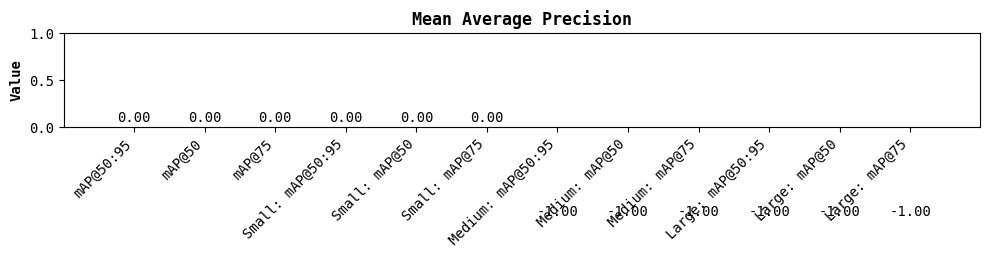

In [14]:
map_metric = MeanAveragePrecision()
map_metric.update(predictions=detections, targets=targets)
map_result = map_metric.compute()
map_result.plot()

In [15]:
from dataclasses import dataclass

print(f"Shape of class_logits: {class_logits.shape}")
print(f"Shape of bbox_coordinates: {bbox_coordinates.shape}")
print(f"Shape of pixel_values: {pixel_values[0].shape}")
print(len(class_logits[0]))



@dataclass
class DetrOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
results = processor.post_process_object_detection(
    outputs=DetrOutput(logits=class_logits[0].unsqueeze(0), pred_boxes=bbox_coordinates[0].unsqueeze(0)),
    target_sizes=[(pixel_values[0].shape[1], pixel_values[0].shape[2])], threshold=0.5
)

label_results = processor.post_process_object_detection(
    outputs=DetrOutput(logits=predictions["logits"].unsqueeze(0), pred_boxes=labels[0]["boxes"].unsqueeze(0)),
    target_sizes=[(pixel_values[0].shape[1], pixel_values[0].shape[2])], threshold=0.5
)


Shape of class_logits: torch.Size([32, 100, 92])
Shape of bbox_coordinates: torch.Size([32, 100, 4])
Shape of pixel_values: torch.Size([3, 1207, 1333])
100


In [16]:
print(f"Predicted class labels: {argmax_predictions.cpu()}")
print(f"Predicted class labels (after post-processing): {results[0]['labels'].cpu()}")

print(f"Matched class labels: {matched_labels['labels'].cpu()}")
print(f"Ground truth class labels: {labels[0]['class_labels'].cpu()}")

Predicted class labels: tensor([86,  1, 64, 72, 91, 62, 62, 72, 62, 44, 78, 91, 67, 86, 91,  1, 62, 82,
        91, 85])
Predicted class labels (after post-processing): tensor([86,  1, 64, 86, 67, 72, 67, 62, 62, 72, 62, 86, 86, 44, 78, 82, 82, 82,
        64, 86, 67, 62, 86, 86, 62,  1, 62, 82, 85])
Matched class labels: tensor([86,  1, 64, 72, 84, 62, 62, 72, 62, 84, 78, 86, 67, 86, 86,  1, 62, 82,
        62, 85])
Ground truth class labels: tensor([64, 72, 72, 62, 62, 62, 62,  1,  1, 78, 82, 84, 84, 85, 86, 86, 62, 86,
        86, 67])


In [17]:
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush', "N/A"
]

CLASSES_WITHOUT_NA = [cls for cls in CLASSES if cls != "N/A"]

print(len(CLASSES))

print(f"Predicted class labels: {[CLASSES[label] for label in argmax_predictions.cpu()]}")
print(f"Predicted class labels (after post-processing): {[CLASSES[label] for label in results[0]['labels'].cpu()]}")
print(f"Matched class labels: {[CLASSES[label] for label in matched_labels['labels'].cpu()]}")
print(f"Ground truth class labels: {[CLASSES[label] for label in labels[0]['class_labels'].cpu()]}")

92
Predicted class labels: ['vase', 'person', 'potted plant', 'tv', 'N/A', 'chair', 'chair', 'tv', 'chair', 'bottle', 'microwave', 'N/A', 'dining table', 'vase', 'N/A', 'person', 'chair', 'refrigerator', 'N/A', 'clock']
Predicted class labels (after post-processing): ['vase', 'person', 'potted plant', 'vase', 'dining table', 'tv', 'dining table', 'chair', 'chair', 'tv', 'chair', 'vase', 'vase', 'bottle', 'microwave', 'refrigerator', 'refrigerator', 'refrigerator', 'potted plant', 'vase', 'dining table', 'chair', 'vase', 'vase', 'chair', 'person', 'chair', 'refrigerator', 'clock']
Matched class labels: ['vase', 'person', 'potted plant', 'tv', 'book', 'chair', 'chair', 'tv', 'chair', 'book', 'microwave', 'vase', 'dining table', 'vase', 'vase', 'person', 'chair', 'refrigerator', 'chair', 'clock']
Ground truth class labels: ['potted plant', 'tv', 'tv', 'chair', 'chair', 'chair', 'chair', 'person', 'person', 'microwave', 'refrigerator', 'book', 'book', 'clock', 'vase', 'vase', 'chair', 'vas

In [18]:
len(CLASSES_WITHOUT_NA)

80

In [19]:
label_results

[{'scores': tensor([0.9924, 0.9079, 0.9369, 0.9970, 0.8549, 0.9800, 0.8942, 0.9986, 0.9534,
          0.7088, 0.9701, 0.9158, 0.9980, 0.9920, 0.9432, 0.9141],
         device='cuda:0'),
  'labels': tensor([86,  1, 64, 72, 62, 62, 72, 62, 44, 78, 67, 86,  1, 62, 82, 85],
         device='cuda:0'),
  'boxes': tensor([[ 444.7077,  267.6244,  935.7665,  665.7652],
          [  13.1922,  315.0422,  306.5928,  800.0000],
          [1045.6394,  392.8451, 1201.0000,  800.0000],
          [ 673.6484,  409.4835, 1201.0000,  800.0000],
          [ 775.3956,  418.7981, 1201.0000,  800.0000],
          [ 595.6209,  411.7183, 1201.0000,  800.0000],
          [ 774.6450,  295.9812, 1201.0000,  800.0000],
          [ 721.4069,  323.3991, 1201.0000,  713.9155],
          [ 961.2128,  386.3849, 1201.0000,  800.0000],
          [ 925.3330,  327.3991, 1201.0000,  800.0000],
          [1150.7832,  578.8545, 1201.0000,  800.0001],
          [ 840.2683,  227.4554, 1201.0000,  496.0000],
          [ 658.2231,

In [20]:
detections = Detections.from_transformers(results)
targets = Detections.from_transformers(label_results)

ValueError: The provided Transformers results do not contain any valid fields. Expected fields are 'boxes', 'masks', 'segments_info' or 'segmentation'.

In [ ]:
from matplotlib import pyplot as plt
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]
          
def plot_results(pil_img, prob, labels, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    print(labels.tolist())
    for p, label, (xmin, ymin, xmax, ymax), c in zip(prob, labels.tolist(), boxes.tolist(), COLORS * 100):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        cl = p.argmax()
        text = f'{CLASSES[int(label)]}: {p:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

In [ ]:
from torchvision.transforms.functional import to_pil_image

pil_img = to_pil_image(pixel_values[0].cpu())

[1, 64, 86, 67, 72, 82, 67, 62, 72, 62, 86, 86, 44, 78, 82, 64, 86, 67, 62, 86, 86, 62, 62, 82, 86, 85, 1]


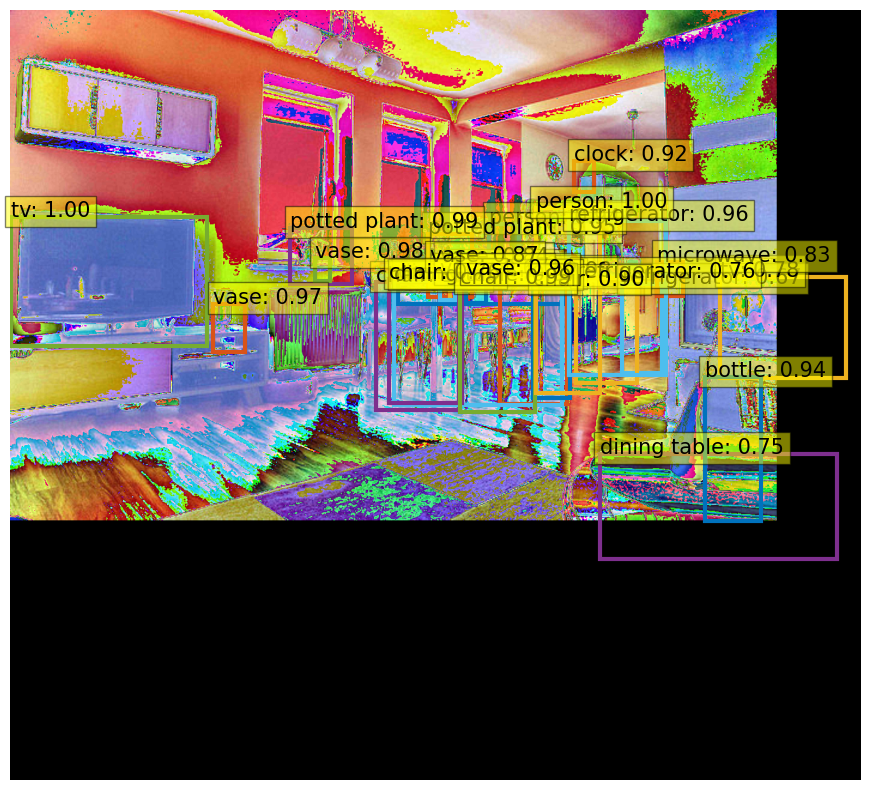

tensor([56, 73, 75, 62, 72, 73, 75, 56, 62, 74, 58, 56, 56, 75,  0, 68, 75, 56,
         0, 60])


In [ ]:
plot_results(pil_img, results[0]["scores"], results[0]["labels"], results[0]["boxes"])
print(matched_labels["labels"].cpu())

[67, 62, 72, 44, 82, 67, 62, 82]


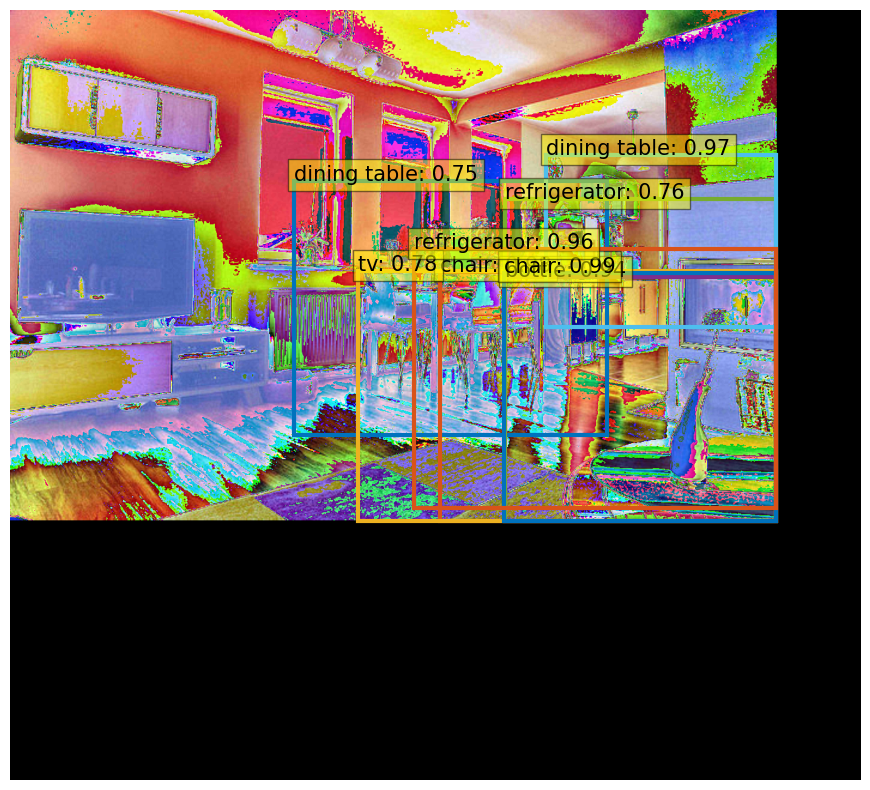

In [ ]:
plot_results(pil_img, label_results[0]["scores"], label_results[0]["labels"], label_results[0]["boxes"])

In [ ]:
matched_labels["labels"]

tensor([56, 56, 68, 73, 75, 72, 73, 75, 56, 62,  0, 58, 56, 56, 75, 75, 62,  0,
        60, 74], device='cuda:0')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..1.8731157].


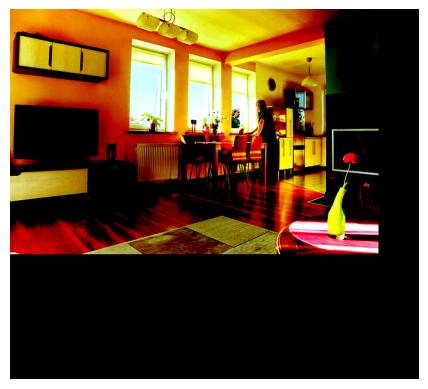

In [ ]:
import matplotlib.pyplot as plt

img = pixel_values[0].cpu()  # move to CPU if needed

# If shape is [C, H, W] → convert to [H, W, C]
if img.ndim == 3:

    img = img.permute(1, 2, 0)

plt.imshow(img)
plt.axis("off")
plt.show()